# Demo of quantum-classic hybird circuit

## Preparation

1. import numpy and pandas
1. prepare matplotlib for drawing
1. import qiskit and display its version table

In [1]:
# Import necessary data-processing modules
import numpy as np
import pandas as pd

# Control matplotlib style (white background)
%matplotlib inline
from matplotlib import style
import matplotlib.pyplot as plt
for s in plt.style.available:
    if s.startswith('seaborn') and s.endswith('white'):
        style.use(s)
        break

# Import QisKit
import qiskit
import qiskit.tools.jupyter
%qiskit_version_table


## Prepare hybird circuit

c:\Users\prett\anaconda3\envs\triq\lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


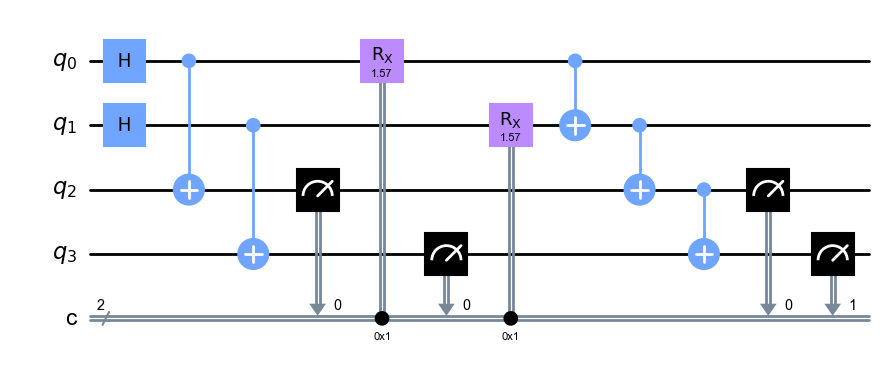

In [2]:
qasm = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg c[2];

h q[0];
h q[1];

cx q[0], q[2];
cx q[1], q[3];

measure q[2] -> c[0];
if (c == 1) rx(1.570796) q[0];

measure q[3] -> c[0];
if (c == 1) rx(1.570796) q[1];

cx q[0], q[1];
cx q[1], q[2];
cx q[2], q[3];

measure q[2] -> c[0];
measure q[3] -> c[1];
"""
circ = qiskit.QuantumCircuit.from_qasm_str(qasm)
circ.draw()


## Try simulate

Simulation result: {'01': 238, '11': 131, '00': 399, '10': 232}


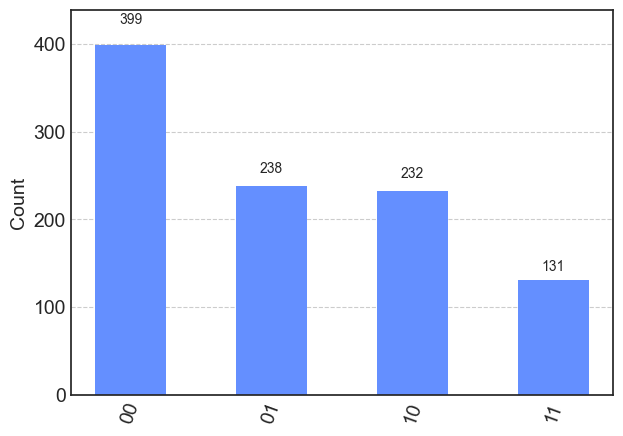

In [3]:
# prepare OpenQasm simulator backend
backend = qiskit.providers.basicaer.QasmSimulatorPy()

# tranpile circuit due to backend
transpiled = qiskit.transpile(circ, backend)

# run circuit in simulator
job = backend.run(transpiled, shots=1000)

# get result and visualization
rst = job.result()
print(f'Simulation result: {rst.get_counts()}')
qiskit.visualization.plot_histogram(rst.get_counts())


## Counter part

Same circuit without hybrid operations

c:\Users\prett\anaconda3\envs\triq\lib\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


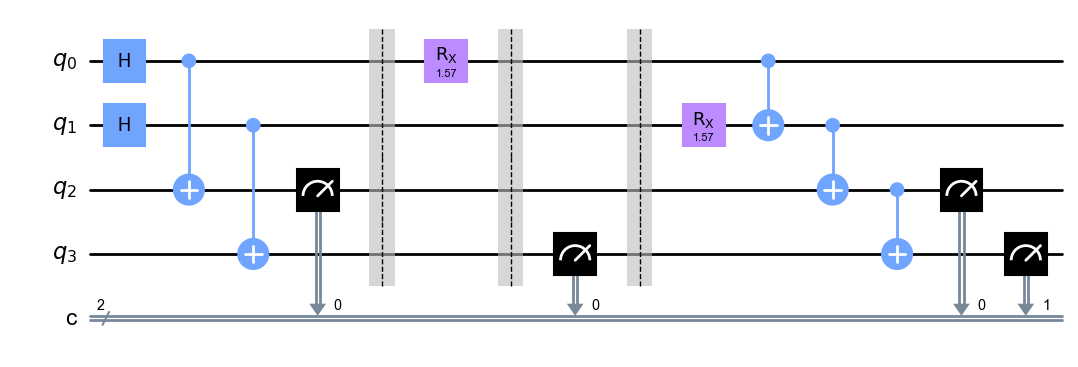

In [4]:
qasm1 = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[4];
creg c[2];

h q[0];
h q[1];

cx q[0], q[2];
cx q[1], q[3];

measure q[2] -> c[0];
barrier q;
rx(1.570796) q[0];

barrier q;
measure q[3] -> c[0];
barrier q;
rx(1.570796) q[1];

cx q[0], q[1];
cx q[1], q[2];
cx q[2], q[3];

measure q[2] -> c[0];
measure q[3] -> c[1];
"""
circ1 = qiskit.QuantumCircuit.from_qasm_str(qasm1)
circ1.draw()


Simulation result: {'10': 272, '00': 218, '11': 250, '01': 260}


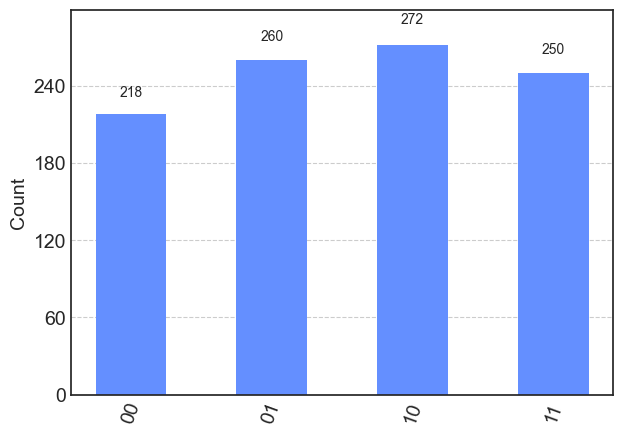

In [5]:
transpiled1 = qiskit.transpile(circ1, backend)
job1 = backend.run(transpiled1, shots=1000)
rst1 = job1.result()
print(f'Simulation result: {rst1.get_counts()}')
qiskit.visualization.plot_histogram(rst1.get_counts())


## Compare

In [6]:
for op in circ.data:
    print(op)


CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0),), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1),), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(QuantumRegister(4, 'q'), 2)), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 3)), clbits=())
CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 2),), clbits=(Clbit(ClassicalRegister(2, 'c'), 0),))
CircuitInstruction(operation=Instruction(name='rx', num_qubits=1, num_clbits=0, params=[1.570796]), qubits=(Qubit(QuantumRegister(4, 'q'), 0),), clbits=(

In [7]:
for op in circ1.data:
    print(op)


CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0),), clbits=())
CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1),), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(QuantumRegister(4, 'q'), 2)), clbits=())
CircuitInstruction(operation=Instruction(name='cx', num_qubits=2, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 3)), clbits=())
CircuitInstruction(operation=Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 2),), clbits=(Clbit(ClassicalRegister(2, 'c'), 0),))
CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(Quantum